In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

from drone_renderer_dynamic import DynamicSceneRenderer, DynamicObstacle
from drone_env import DroneSimulator

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
# ==============================================================================
# 创建动态场景渲染器
# ==============================================================================

renderer = DynamicSceneRenderer(
    static_mesh_path='./data/sample/sample4.obj',
    device=device,
    image_size=(48, 64),
    focal_length=500.0,
    num_samples=50000
)

print(f"静态网格加载完成")
print(f"静态点云数量: {renderer.static_pcd.shape}")

静态网格加载完成
静态点云数量: torch.Size([1, 50000, 3])


In [3]:
# ==============================================================================
# 添加动态障碍物
# ==============================================================================

# 添加移动的球体
renderer.add_primitive_obstacle(
    primitive_type='sphere',
    position=torch.tensor([1.0, 0.0, 0.0], device=device),
    velocity=torch.tensor([0.0, 0.3, 0.0], device=device),  # 沿 Y 轴移动
    scale=0.3,
    color=[1.0, 0.0, 0.0]  # 红色
)

# 添加移动的立方体
renderer.add_primitive_obstacle(
    primitive_type='cube',
    position=torch.tensor([-1.0, 1.0, 0.5], device=device),
    velocity=torch.tensor([0.2, -0.1, 0.0], device=device),
    scale=0.4,
    color=[0.0, 1.0, 0.0]  # 绿色
)

# 添加静止的球体
renderer.add_primitive_obstacle(
    primitive_type='sphere',
    position=torch.tensor([0.0, -1.0, 0.0], device=device),
    velocity=torch.tensor([0.0, 0.0, 0.0], device=device),  # 静止
    scale=0.5,
    color=[0.0, 0.0, 1.0]  # 蓝色
)

print(f"动态障碍物数量: {len(renderer.dynamic_obstacles)}")
print(f"总点云数量: {renderer.obstacle_pcd.shape}")

动态障碍物数量: 3
总点云数量: torch.Size([1, 51500, 3])


In [4]:
# ==============================================================================
# 渲染动态场景序列
# ==============================================================================

# 设置相机位置 (模拟无人机视角)
cam_pos = torch.tensor([[-3.0, 0.0, 0.5]], device=device)  # 相机位置
cam_R = torch.eye(3, device=device).unsqueeze(0)  # 相机朝向

# 渲染一系列帧
frames = []
n_frames = 60
dt = 0.1  # 时间步长

for i in range(n_frames):
    # 计算视图矩阵
    R_view, T_view = renderer.compute_view_matrix(
        p_ros=cam_pos,
        R_ros=cam_R,
        camera_pitch_deg=10.0
    )
    
    # 渲染
    rgb, depth = renderer.render(
        R=R_view,
        T=T_view,
        return_tensor=True,
        return_rgb=True,
        return_depth=True
    )
    
    frames.append({
        'rgb': rgb[0].cpu().numpy() if rgb is not None else None,
        'depth': depth[0].cpu().numpy() if depth is not None else None
    })
    
    # 更新障碍物位置
    renderer.step_obstacles(dt)

print(f"渲染完成: {n_frames} 帧")

渲染完成: 60 帧


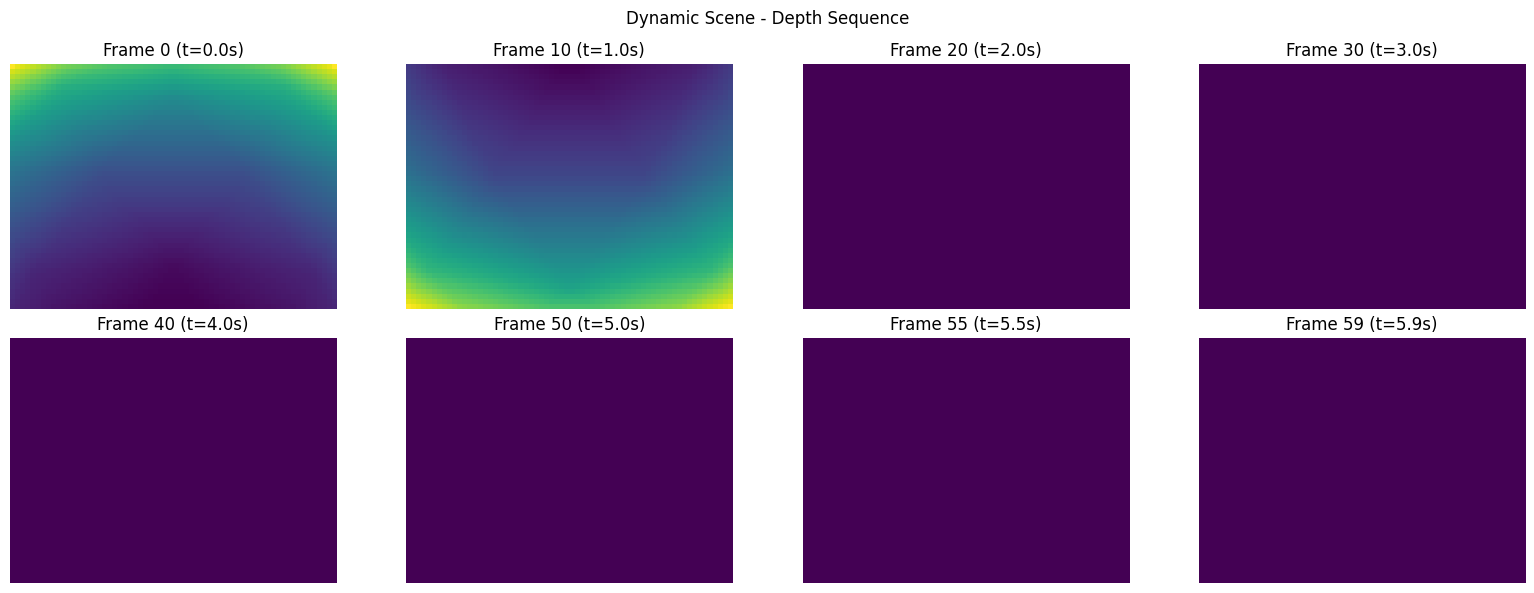

In [5]:
# ==============================================================================
# 可视化帧序列
# ==============================================================================

fig, axes = plt.subplots(2, 4, figsize=(16, 6))

# 选择要显示的帧
frame_indices = [0, 10, 20, 30, 40, 50, 55, 59]

for idx, frame_idx in enumerate(frame_indices):
    row = idx // 4
    col = idx % 4
    
    depth = frames[frame_idx]['depth']
    if depth is not None:
        axes[row, col].imshow(depth, cmap='viridis')
        axes[row, col].set_title(f'Frame {frame_idx} (t={frame_idx * dt:.1f}s)')
        axes[row, col].axis('off')

plt.suptitle('Dynamic Scene - Depth Sequence')
plt.tight_layout()
plt.show()

In [6]:
# ==============================================================================
# 创建动画
# ==============================================================================

fig, ax = plt.subplots(figsize=(8, 6))

# 初始化图像
im = ax.imshow(frames[0]['depth'], cmap='viridis', animated=True)
ax.axis('off')
title = ax.set_title('Frame 0')

def update(frame_idx):
    im.set_array(frames[frame_idx]['depth'])
    title.set_text(f'Frame {frame_idx} (t={frame_idx * dt:.1f}s)')
    return [im, title]

ani = animation.FuncAnimation(
    fig, update, frames=n_frames,
    interval=100, blit=True
)

plt.close()  # 防止重复显示
HTML(ani.to_jshtml())

随机生成 5 个障碍物


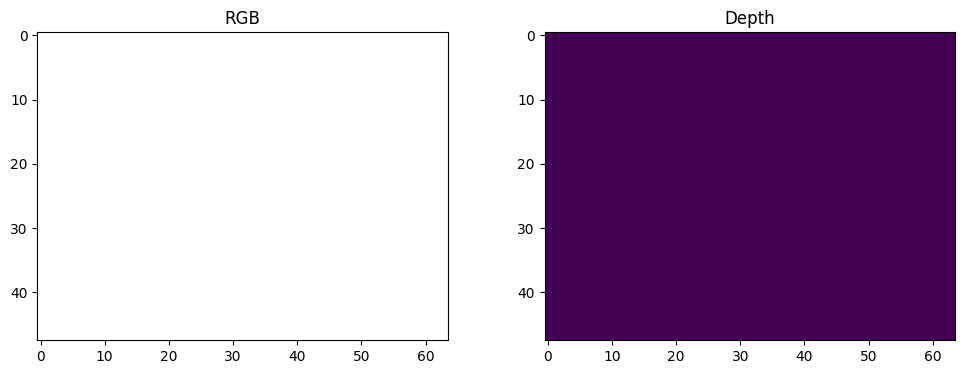

In [7]:
# ==============================================================================
# 测试随机化动态障碍物
# ==============================================================================

# 清除之前的障碍物
renderer.clear_dynamic_obstacles()

# 随机化生成新障碍物
renderer.randomize_obstacles(
    num_obstacles=5,
    position_range=(-1.5, 1.5),
    velocity_range=(-0.3, 0.3),
    scale_range=(0.2, 0.6)
)

print(f"随机生成 {len(renderer.dynamic_obstacles)} 个障碍物")

# 渲染一帧看看
R_view, T_view = renderer.compute_view_matrix(
    p_ros=cam_pos,
    R_ros=cam_R,
    camera_pitch_deg=10.0
)

rgb, depth = renderer.render(R=R_view, T=T_view, return_tensor=True, return_rgb=True, return_depth=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if rgb is not None:
    axes[0].imshow(rgb[0].cpu().numpy())
    axes[0].set_title('RGB')
if depth is not None:
    axes[1].imshow(depth[0].cpu().numpy(), cmap='viridis')
    axes[1].set_title('Depth')
plt.show()

In [8]:
# ==============================================================================
# 与训练循环集成示例
# ==============================================================================

# 示例：在每个 episode 开始时随机化障碍物
def train_with_dynamic_obstacles(renderer, num_episodes=10):
    for episode in range(num_episodes):
        # 每个 episode 随机化障碍物配置
        renderer.randomize_obstacles(
            num_obstacles=np.random.randint(2, 6),  # 2-5个障碍物
            position_range=(-2.0, 2.0),
            velocity_range=(-0.5, 0.5),
            scale_range=(0.2, 0.8)
        )
        
        print(f"Episode {episode}: {len(renderer.dynamic_obstacles)} 动态障碍物")
        
        # 模拟 episode 中的步骤
        for step in range(10):
            # 更新障碍物位置
            renderer.step_obstacles(dt=0.05)
            
            # 这里可以进行渲染和模型推理
            # ...

train_with_dynamic_obstacles(renderer, num_episodes=5)

Episode 0: 3 动态障碍物
Episode 1: 2 动态障碍物
Episode 2: 5 动态障碍物
Episode 3: 4 动态障碍物
Episode 4: 2 动态障碍物
